# Model Motivation & Description

## Motivation
Thomas Boyer-Kassem's framework argues that **Majority Judgment (MJ)** should replace simple majority voting in epistemic contexts because it respects the *Domination axiom* and aggregates qualitative grades rather than binary votes. However, MJ's conservative tie-breaking rule intentionally favors "consensus" (grades clustered near the median), which may sacrifice truth-tracking performance when high-grade outliers genuinely signal the true hypothesis. 

This simulation tests whether **risk-sensitive aggregation variants**—and their "radical" counterparts that discard the Domination axiom—outperform MJ in epistemic accuracy. By systematically relaxing MJ's consensus bias, we evaluate how different aggregation philosophies perform under varying agent competence and option complexity.

## Model Setup
- **Hypotheses**: Each round presents `n_options` mutually exclusive factual propositions. Exactly one is true.
- **Truth Assignment**: The true hypothesis receives grade `E` (Excellent); all others receive `G` (Good).
- **Agent Evaluation**: `n_agents` independently grade all options. With probability `competence`, an agent outputs the true grade for each proposition. Otherwise, they draw uniformly from `{P, F, G, VG, E}`.
- **Output**: An `n_agents × n_options` grade matrix is aggregated to select the group's best hypothesis.

## Aggregation Rules
All graded rules first compare **majority grades** (medians). If medians are equal, standard rules check for **strict domination** (where one profile dominates another element-wise). If neither resolves the comparison, they diverge at the tie-breaking stage or skip domination entirely:

| Rule | Logic |
|------|-------|
| **MJ** | **Standard**: Compares median, checks domination, then uses strict interval expansion (preferring *dominance* then *concision*). |
| **RE** (Risk-Embracing) | **Standard**: After median/domination, compares **right-tail grades** (higher = better). Favors outlier potential. |
| **RAV** (Risk-Averse) | **Standard**: After median/domination, compares **left-tail grades** (higher = less bad). Favors safety. |
| **RE_RAD** (Radical RE) | **Radical**: Skips domination check entirely. Compares **right-tail grades** directly after median. Maximizes sensitivity to high outliers. |
| **RAV_RAD** (Radical RAV) | **Radical**: Skips domination check entirely. Compares **left-tail grades** directly after median. Maximizes sensitivity to low outliers. |
| **SMR** (Simple Majority) | Counts how many agents gave each option their highest grade. Selects the option with the most top-grade votes. Ignores full grade profiles. |

## Experimental Design
- **Sweep Parameters**: 
  - Competence: `[0.3, 0.5, 0.7]`
  - Options: `[3, 5]`
  - Rounds: `5,000` per configuration
- **Metric**: True Positive Rate (TP%) – frequency with which the rule correctly identifies the true hypothesis.
- **Goal**: Visualize how rule performance shifts with competence and option count, testing whether risk-sensitive variants (especially radical ones) trade off epistemic conservatism for higher truth-tracking under noise or high uncertainty.


### Key Findings (AI generated)

1.  **SMR is Fragile:** Simple Majority Rule performs well only when agents are incompetent (~30%). It collapses at high competence (0.7) with many options (42.9%) due to "distractor inflation"—noise creates false ties that SMR cannot resolve.
2.  **MJ is Robust but Conservative:** Majority Judgment maintains high accuracy (75–99%) across all settings. However, its tie-breaking rule (favoring consensus/concision) is epistemically conservative, often preferring "boring" uniform grades over "polarized" profiles that may contain the true signal (an `E` grade).
3.  **Risk-Sensitive Variants Outperform MJ:**
    *   **RE (Risk-Embracing)** significantly outperforms MJ at low-to-medium competence (e.g., 84.3% vs 75.8% at 0.3). By prioritizing high outliers, RE is better at detecting "breakthrough" hypotheses in noisy environments.
    *   **RAV (Risk-Averse)** slightly outperforms MJ at high competence (100% vs 99.7%). By penalizing "bad tails," RAV is more effective at rejecting false hypotheses that mimic the true median but have lower minimum grades.
4.  **Conclusion:** MJ’s strict adherence to consensus is suboptimal for truth-tracking. Relaxing the tie-breaking rule to prioritize either **potential** (RE) or **safety** (RAV) yields superior epistemic performance, validating the need for context-sensitive aggregation in scientific inquiry.


Running sweep for 6 rules...
Sweep complete. Generating TP% grid...



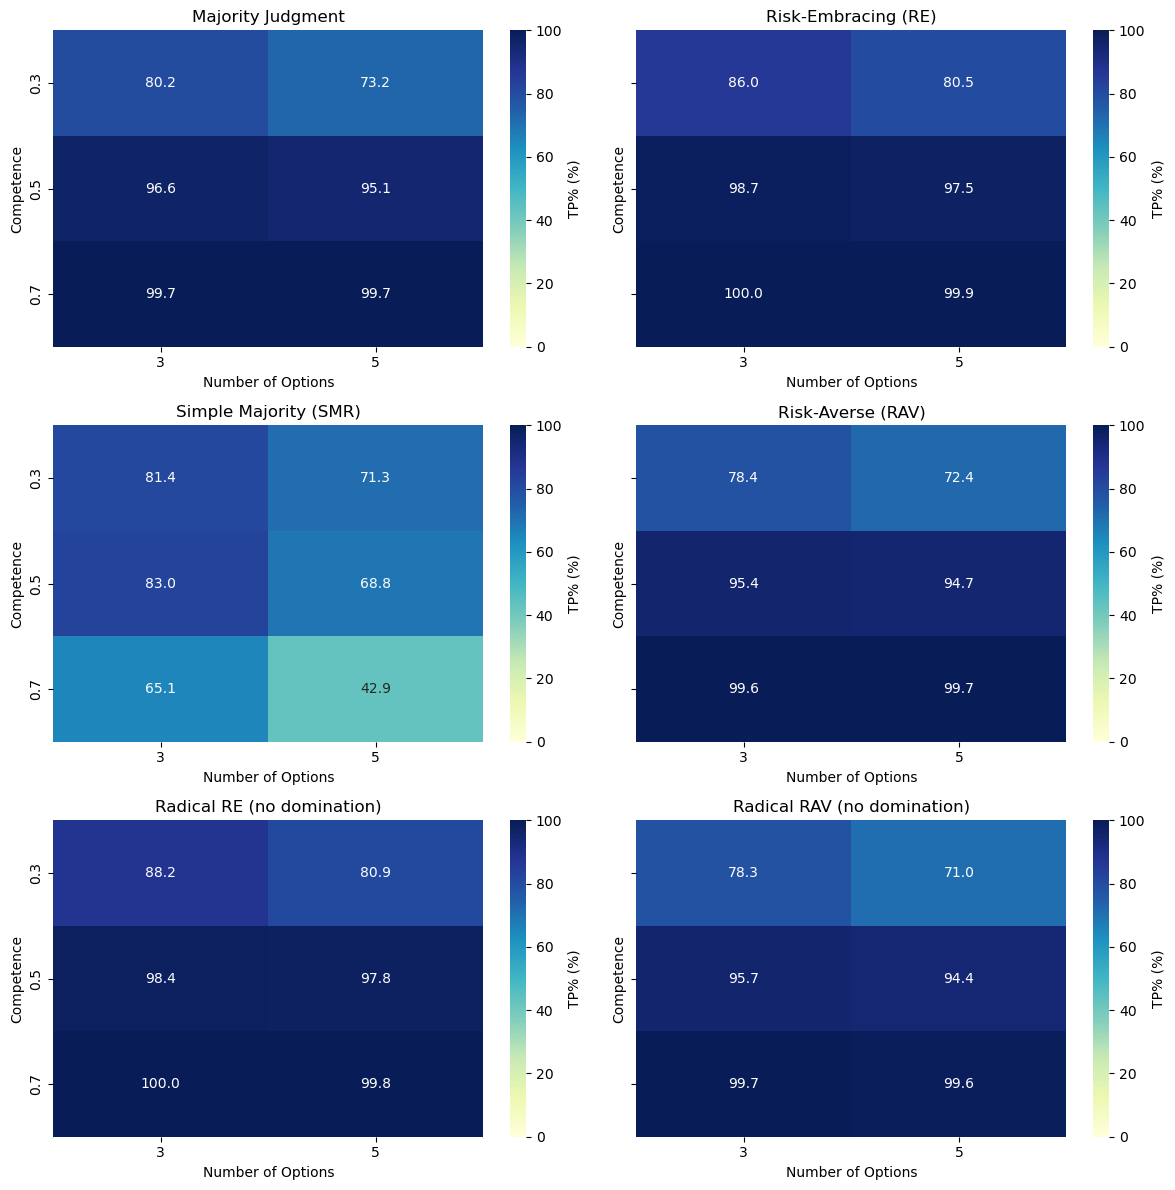

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from enum import IntEnum

# ─────────────────────────────────────────────────────────────────────────────
# 1. GRADES & SIMULATION
# ─────────────────────────────────────────────────────────────────────────────
class Grade(IntEnum):
    P = 0; F = 1; G = 2; VG = 3; E = 4

def majority_grade(grades: np.ndarray) -> int:
    """Returns the median grade (Majority Grade)."""
    sorted_g = np.sort(grades)[::-1]
    return sorted_g[(len(sorted_g) - 1) // 2]

def dominates(sorted_a: np.ndarray, sorted_b: np.ndarray) -> bool:
    """Strict Domination: a dominates b if all a_i >= b_i and at least one a_i > b_i."""
    return np.all(sorted_a >= sorted_b) and np.any(sorted_a > sorted_b)

def get_interval_scores(grades: np.ndarray, median: int):
    """
    Extracts grades strictly above and below the median.
    R_list: grades > median, sorted descending (R1, R2, ...)
    L_list: grades < median, sorted ascending (L1, L2, ...)
    """
    sorted_g = np.sort(grades)[::-1]
    above = sorted_g[sorted_g > median]
    below = np.sort(sorted_g[sorted_g < median])
    return above, below

def compare_mj(grades_a: np.ndarray, grades_b: np.ndarray) -> str:
    sorted_a = np.sort(grades_a)[::-1]
    sorted_b = np.sort(grades_b)[::-1]
    
    med_a = majority_grade(grades_a)
    med_b = majority_grade(grades_b)
    
    # 1. Compare Median
    if med_a > med_b: return 'A'
    if med_b > med_a: return 'B'
    
    # 2. Medians equal. Check Domination
    if dominates(sorted_a, sorted_b): return 'A'
    if dominates(sorted_b, sorted_a): return 'B'
    
    # 2. Interval Expansion
    above_a, below_a = get_interval_scores(grades_a, med_a)
    above_b, below_b = get_interval_scores(grades_b, med_b)
    
    max_len = max(len(above_a), len(below_a), len(above_b), len(below_b))
    
    for k in range(1, max_len + 2):
        r1 = above_a[k-1] if k-1 < len(above_a) else -1
        r2 = above_b[k-1] if k-1 < len(above_b) else -1
        l1 = below_a[k-1] if k-1 < len(below_a) else -1
        l2 = below_b[k-1] if k-1 < len(below_b) else -1
        
        # 2.1 Dominant Option Wins
        cond_2_wins = (l1 <= l2 and r1 < r2) or (l1 < l2 and r1 <= r2)
        if cond_2_wins: return 'B'
        cond_1_wins = (l2 <= l1 and r2 < r1) or (l2 < l1 and r2 <= r1)
        if cond_1_wins: return 'A'
        
        # 2.2 Concision Wins
        concision_1_wins = (l1 >= l2 and r1 < r2) or (l1 > l2 and r1 <= r2)
        if concision_1_wins: return 'A'
        concision_2_wins = (l2 >= l1 and r2 < r1) or (l2 > l1 and r2 <= r1)
        if concision_2_wins: return 'B'
        
    return 'TIE'

def compare_re(grades_a: np.ndarray, grades_b: np.ndarray) -> str:
    """Risk Embracing: Compare Right grades after median/domination check."""
    sorted_a = np.sort(grades_a)[::-1]
    sorted_b = np.sort(grades_b)[::-1]
    med_a = majority_grade(grades_a)
    med_b = majority_grade(grades_b)
    
    if med_a > med_b: return 'A'
    if med_b > med_a: return 'B'
    if dominates(sorted_a, sorted_b): return 'A'
    if dominates(sorted_b, sorted_a): return 'B'
    
    above_a, _ = get_interval_scores(grades_a, med_a)
    above_b, _ = get_interval_scores(grades_b, med_b)
    max_len = max(len(above_a), len(above_b))
    for k in range(max_len):
        r1 = above_a[k] if k < len(above_a) else -1
        r2 = above_b[k] if k < len(above_b) else -1
        if r1 > r2: return 'A'
        if r2 > r1: return 'B'
    return compare_mj(grades_a, grades_b)

def compare_rav(grades_a: np.ndarray, grades_b: np.ndarray) -> str:
    """Risk Averse: Compare Left grades after median/domination check."""
    sorted_a = np.sort(grades_a)[::-1]
    sorted_b = np.sort(grades_b)[::-1]
    med_a = majority_grade(grades_a)
    med_b = majority_grade(grades_b)
    
    if med_a > med_b: return 'A'
    if med_b > med_a: return 'B'
    if dominates(sorted_a, sorted_b): return 'A'
    if dominates(sorted_b, sorted_a): return 'B'
    
    _, below_a = get_interval_scores(grades_a, med_a)
    _, below_b = get_interval_scores(grades_b, med_b)
    max_len = max(len(below_a), len(below_b))
    for k in range(max_len):
        l1 = below_a[k] if k < len(below_a) else -1
        l2 = below_b[k] if k < len(below_b) else -1
        if l1 > l2: return 'A'
        if l2 > l1: return 'B'
    return compare_mj(grades_a, grades_b)

def compare_re_radical(grades_a: np.ndarray, grades_b: np.ndarray) -> str:
    """Radical RE: Skips domination check. Compares right tails directly."""
    sorted_a = np.sort(grades_a)[::-1]
    sorted_b = np.sort(grades_b)[::-1]
    med_a = majority_grade(grades_a)
    med_b = majority_grade(grades_b)
    
    if med_a > med_b: return 'A'
    if med_b > med_a: return 'B'
    # DOMINATION CHECK SKIPPED
    
    above_a, _ = get_interval_scores(grades_a, med_a)
    above_b, _ = get_interval_scores(grades_b, med_b)
    max_len = max(len(above_a), len(above_b))
    for k in range(max_len):
        r1 = above_a[k] if k < len(above_a) else -1
        r2 = above_b[k] if k < len(above_b) else -1
        if r1 > r2: return 'A'
        if r2 > r1: return 'B'
    return compare_mj(grades_a, grades_b)

def compare_rav_radical(grades_a: np.ndarray, grades_b: np.ndarray) -> str:
    """Radical RAV: Skips domination check. Compares left tails directly."""
    sorted_a = np.sort(grades_a)[::-1]
    sorted_b = np.sort(grades_b)[::-1]
    med_a = majority_grade(grades_a)
    med_b = majority_grade(grades_b)
    
    if med_a > med_b: return 'A'
    if med_b > med_a: return 'B'
    # DOMINATION CHECK SKIPPED
    
    _, below_a = get_interval_scores(grades_a, med_a)
    _, below_b = get_interval_scores(grades_b, med_b)
    max_len = max(len(below_a), len(below_b))
    for k in range(max_len):
        l1 = below_a[k] if k < len(below_a) else -1
        l2 = below_b[k] if k < len(below_b) else -1
        if l1 > l2: return 'A'
        if l2 > l1: return 'B'
    return compare_mj(grades_a, grades_b)

def select_best(grades_matrix: np.ndarray, rule: str) -> int:
    n_options = grades_matrix.shape[1]
    if rule == 'SMR':
        votes = np.zeros(n_options, dtype=int)
        max_grades = np.max(grades_matrix, axis=0)
        for j in range(n_options):
            votes[j] = np.sum(grades_matrix[:, j] == max_grades[j])
        max_votes = np.max(votes)
        candidates = np.where(votes == max_votes)[0]
        return np.random.choice(candidates)
    else:
        best = 0
        for j in range(1, n_options):
            if rule == 'MJ':
                cmp = compare_mj(grades_matrix[:, best], grades_matrix[:, j])
            elif rule == 'RE':
                cmp = compare_re(grades_matrix[:, best], grades_matrix[:, j])
            elif rule == 'RAV':
                cmp = compare_rav(grades_matrix[:, best], grades_matrix[:, j])
            elif rule == 'RE_RAD':
                cmp = compare_re_radical(grades_matrix[:, best], grades_matrix[:, j])
            elif rule == 'RAV_RAD':
                cmp = compare_rav_radical(grades_matrix[:, best], grades_matrix[:, j])
            else:
                raise ValueError(f"Unknown rule: {rule}")
            if cmp == 'B':
                best = j
        return best

def simulate_round(n_agents: int, n_options: int, competence: float, truth_idx: int, rule: str) -> int:
    true_grades = np.full(n_options, Grade.G, dtype=int)
    true_grades[truth_idx] = Grade.E
    grades_matrix = np.zeros((n_agents, n_options), dtype=int)
    for i in range(n_agents):
        for j in range(n_options):
            if np.random.rand() < competence:
                grades_matrix[i, j] = true_grades[j]
            else:
                grades_matrix[i, j] = np.random.choice([Grade.P, Grade.F, Grade.G, Grade.VG, Grade.E])
    return select_best(grades_matrix, rule)

# ─────────────────────────────────────────────────────────────────────────────
# 2. SWEEP & DATA COLLECTION
# ─────────────────────────────────────────────────────────────────────────────
def run_sweep(n_rounds: int = 5000, seed: int = 42) -> pd.DataFrame:
    np.random.seed(seed)
    competences = [0.3, 0.5, 0.7]
    n_options_list = [3, 5]
    rules = ['MJ', 'RE', 'SMR', 'RAV', 'RE_RAD', 'RAV_RAD']
    
    records = []
    for rule in rules:
        for n_opt in n_options_list:
            for comp in competences:
                tp = 0
                for _ in range(n_rounds):
                    truth_idx = np.random.randint(0, n_opt)
                    selected = simulate_round(n_agents=10, n_options=n_opt, 
                                              competence=comp, truth_idx=truth_idx, rule=rule)
                    if selected == truth_idx: tp += 1
                records.append({
                    'Rule': rule,
                    'Competence': comp,
                    'Options': n_opt,
                    'TP%': tp / n_rounds * 100
                })
    return pd.DataFrame(records)

# ─────────────────────────────────────────────────────────────────────────────
# 3. 3x2 HEATMAP GRID
# ─────────────────────────────────────────────────────────────────────────────
def plot_tp_grid(df: pd.DataFrame):
    fig, axes = plt.subplots(3, 2, figsize=(12, 12), sharey=True)
    rules = ['MJ', 'RE', 'SMR', 'RAV', 'RE_RAD', 'RAV_RAD']
    titles = ['Majority Judgment', 'Risk-Embracing (RE)', 'Simple Majority (SMR)', 
              'Risk-Averse (RAV)', 'Radical RE (no domination)', 'Radical RAV (no domination)']
    
    for ax, rule, title in zip(axes.ravel(), rules, titles):
        rule_df = df[df['Rule'] == rule]
        pivot = rule_df.pivot(index='Competence', columns='Options', values='TP%')
        sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlGnBu",
                    ax=ax, cbar_kws={'label': 'TP% (%)'}, vmin=0, vmax=100)
        ax.set_title(title)
        ax.set_xlabel('Number of Options')
        ax.set_ylabel('Competence')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
        
    axes[-1, 0].set_ylabel('Competence')
    plt.tight_layout()
    plt.show()

# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    print("Running sweep for 6 rules...")
    results_df = run_sweep()
    print("Sweep complete. Generating TP% grid...\n")
    plot_tp_grid(results_df)


### Key Findings (AI generated)

1.  **SMR is Fragile:** Simple Majority Rule performs well only when agents are incompetent (~30%). It collapses at high competence (0.7) with many options (42.9%) due to "distractor inflation"—noise creates false ties that SMR cannot resolve.
2.  **Radical RE is the Epistemic Winner:** By skipping the domination check and prioritizing the right tail, **Radical RE (RE_RAD)** significantly outperforms all other rules. At competence 0.3, it reaches **88.2%** (vs. MJ's 80.2%), proving that sensitivity to high-grade outliers is crucial for truth-tracking in noisy environments. It achieves 100% accuracy at competence 0.7, matching the theoretical limit.
3.  **MJ’s Bottleneck is "Concision," Not Domination:** MJ performs robustly (99.7% at high competence) but is consistently outperformed by RE and RE_RAD at lower competence levels. This suggests that MJ’s tie-breaking preference for "concise" (uniform) profiles penalizes the true hypothesis, which often has a polarized profile (`{E, G, G, G, F}`). MJ’s conservatism prevents it from "seeing" the `E` signal when medians are tied at `G`.
4.  **Radical RAV is a Robust Alternative:** **Radical RAV (RAV_RAD)** closely tracks MJ (e



# Deliberation Model: Research Question & Setup

## Research Question
In epistemic settings, **deliberation** is often assumed to improve collective accuracy by allowing agents to share reasons and correct errors. One can also ask: **Can deliberation amplify noise?** 

Specifically, we ask:
1.  Does **team composition** (Expert vs. Diverse) interact with **aggregation rules** (MJ, RE, RAV, and their Radical variants) to determine whether deliberation helps or harms truth-tracking?
2.  Under what conditions does **diversity** become a superior source of robustness compared to **expertise**?
3.  Do **Radical** aggregation rules (which skip strict axiomatic checks like Domination) outperform standard Majority Judgment in deliberative environments?

## Model Setup
This simulation extends the previous static model by adding a **deliberation phase** where agents update their grades based on group consensus.

### 1. Team Generation (inspired by Hijn Duif's paper)
*   **Expert Teams:** All agents rely on the same top-$k$ most reliable sources. This creates **high homogeneity** and shared noise.
*   **Diverse Teams:** Agents are assigned distinct sources to minimize overlap. This creates **high independence**, allowing errors to average out.

### 2. Evidence & Deliberation
1.  **Initial Evidence:** Each agent aggregates noisy signals from their sources to form an initial grade for each hypothesis.
2.  **Deliberation Round:** Agents share their grades. Each agent updates their grade for a proposition by taking the **majority vote** of the entire group’s current grades for that proposition.
    *   *Note:* This simple "bandwagon" effect can lead to **echo chambers** (if the group is wrong, they become more wrong) or **information pooling** (if diverse signals converge on the truth). Since majority voting washes out extremes, we might want to also study other pooling methods.

### 3. Aggregation Rules
After deliberation, the group uses one of six rules to select the best hypothesis:
*   **MJ:** Strict Majority Judgment (Median → Domination → Interval Expansion).
*   **RE / RAV:** Risk-Embracing (prioritizes high outliers) and Risk-Averse (prioritizes safety/low tails) variants.
*   **RE_RAD / RAV_RAD:** **Radical** variants that skip the Domination check, allowing for more aggressive tie-breaking based on tail grades.
*   **SMR:** Simple Majority Rule (baseline, often vulnerable to noise).

### 4. Experimental Variables
*   **Source Reliability:** Swept from 0.55 to 0.75 to model varying levels of expertise quality.
*   **Number of Options:** Both **3** and **5** options are tested to see if problem difficulty affects the results.
*   **Performance Metric:** True Positive % (TP%) – the frequency with which the rule correctly identifies the true hypothesis.


Running diversity-expertise sweep with 6 rules and 2 option counts...
Sweep complete. Generating trade-off curves...



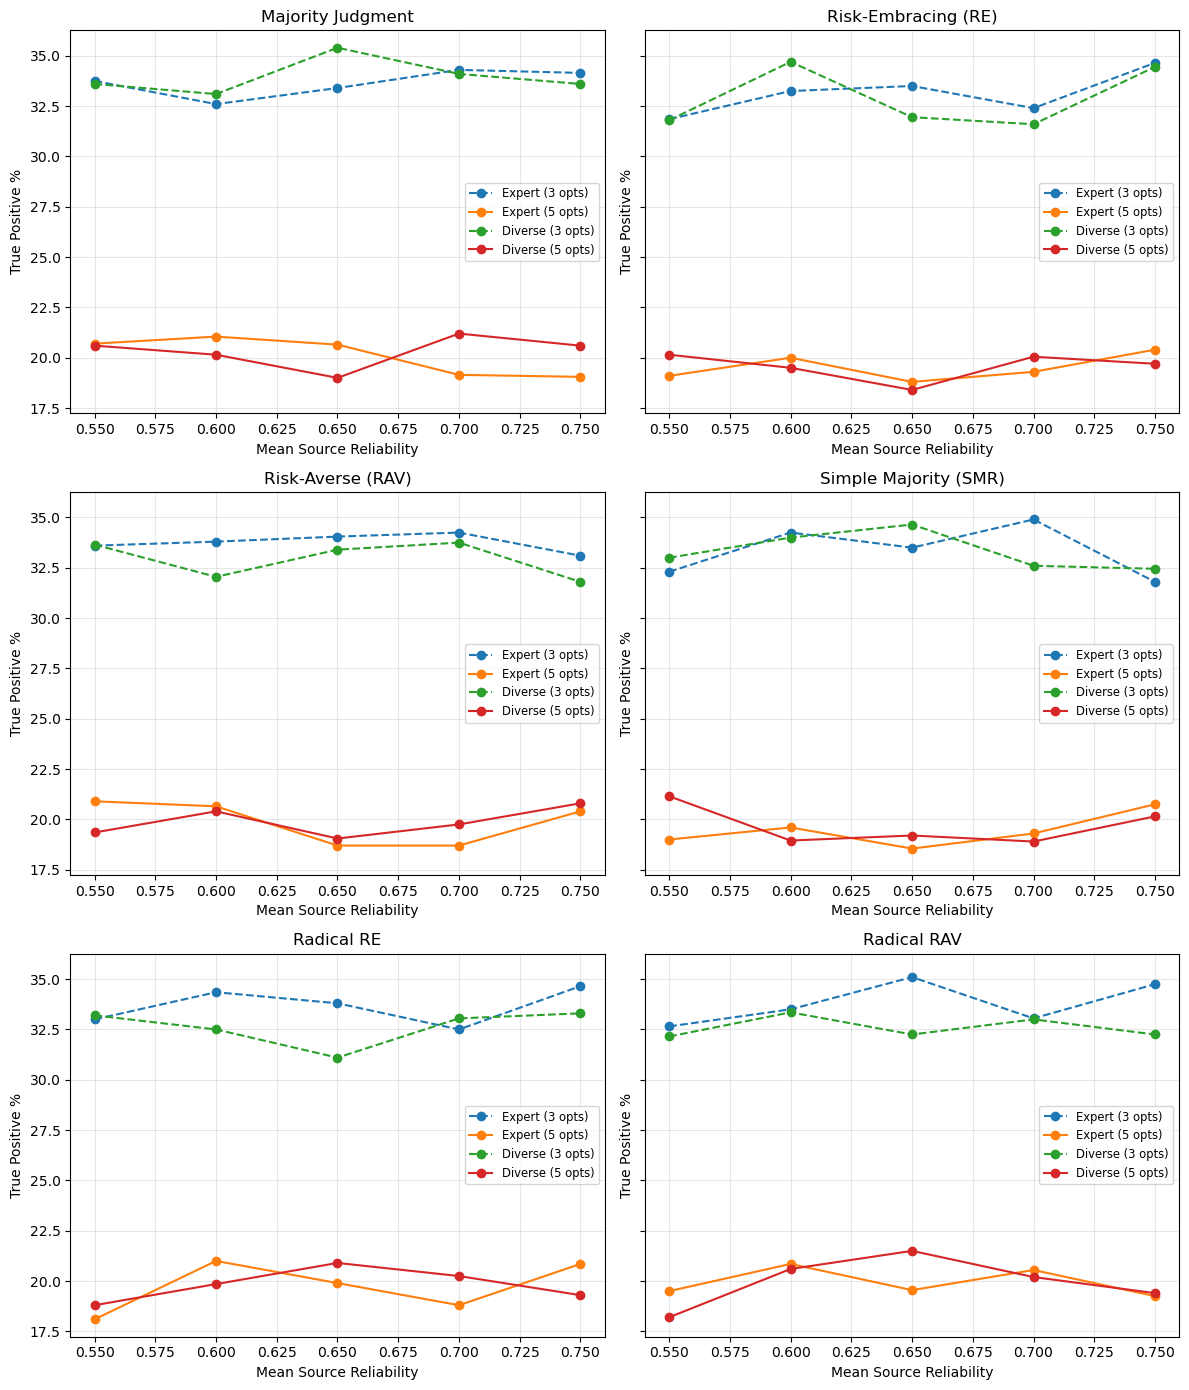

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from enum import IntEnum
from itertools import combinations

# ─────────────────────────────────────────────────────────────────────────────
# 1. GRADES & SIMULATION
# ─────────────────────────────────────────────────────────────────────────────
class Grade(IntEnum):
    P = 0; F = 1; G = 2; VG = 3; E = 4

def majority_grade(grades: np.ndarray) -> int:
    """Returns the median grade (Majority Grade)."""
    sorted_g = np.sort(grades)[::-1]
    return sorted_g[(len(sorted_g) - 1) // 2]

def dominates(sorted_a: np.ndarray, sorted_b: np.ndarray) -> bool:
    """Strict Domination: a dominates b if all a_i >= b_i and at least one a_i > b_i."""
    return np.all(sorted_a >= sorted_b) and np.any(sorted_a > sorted_b)

def get_interval_scores(grades: np.ndarray, median: int):
    """
    Extracts grades strictly above and below the median.
    R_list: grades > median, sorted descending (R1, R2, ...)
    L_list: grades < median, sorted ascending (L1, L2, ...)
    """
    sorted_g = np.sort(grades)[::-1]
    above = sorted_g[sorted_g > median]
    below = np.sort(sorted_g[sorted_g < median])
    return above, below

def compare_mj(grades_a: np.ndarray, grades_b: np.ndarray) -> str:
    """
    Strict Majority Judgment comparison.
    1. Compare Medians.
    2. Check Domination.
    3. Interval Expansion: Compare Right/Left tails stepwise.
    """
    sorted_a = np.sort(grades_a)[::-1]
    sorted_b = np.sort(grades_b)[::-1]
    
    med_a = majority_grade(grades_a)
    med_b = majority_grade(grades_b)
    
    # 1. Compare Median
    if med_a > med_b: return 'A'
    if med_b > med_a: return 'B'
    
    # 2. Medians equal. Check Domination
    if dominates(sorted_a, sorted_b): return 'A'
    if dominates(sorted_b, sorted_a): return 'B'
    
    # 3. Interval Expansion
    above_a, below_a = get_interval_scores(grades_a, med_a)
    above_b, below_b = get_interval_scores(grades_b, med_b)
    
    max_len = max(len(above_a), len(below_a), len(above_b), len(below_b))
    
    for k in range(1, max_len + 2):
        r1 = above_a[k-1] if k-1 < len(above_a) else -1
        r2 = above_b[k-1] if k-1 < len(above_b) else -1
        l1 = below_a[k-1] if k-1 < len(below_a) else -1
        l2 = below_b[k-1] if k-1 < len(below_b) else -1
        
        # 2.1 Dominant Option Wins
        cond_2_wins = (l1 <= l2 and r1 < r2) or (l1 < l2 and r1 <= r2)
        if cond_2_wins: return 'B'
        cond_1_wins = (l2 <= l1 and r2 < r1) or (l2 < l1 and r2 <= r1)
        if cond_1_wins: return 'A'
        
        # 2.2 Concision Wins
        concision_1_wins = (l1 >= l2 and r1 < r2) or (l1 > l2 and r1 <= r2)
        if concision_1_wins: return 'A'
        concision_2_wins = (l2 >= l1 and r2 < r1) or (l2 > l1 and r2 <= r1)
        if concision_2_wins: return 'B'
        
    return 'TIE'

def compare_re(grades_a: np.ndarray, grades_b: np.ndarray) -> str:
    """Risk Embracing: Compare Right grades after median/domination check."""
    sorted_a = np.sort(grades_a)[::-1]
    sorted_b = np.sort(grades_b)[::-1]
    med_a = majority_grade(grades_a)
    med_b = majority_grade(grades_b)
    
    if med_a > med_b: return 'A'
    if med_b > med_a: return 'B'
    if dominates(sorted_a, sorted_b): return 'A'
    if dominates(sorted_b, sorted_a): return 'B'
    
    above_a, _ = get_interval_scores(grades_a, med_a)
    above_b, _ = get_interval_scores(grades_b, med_b)
    max_len = max(len(above_a), len(above_b))
    for k in range(max_len):
        r1 = above_a[k] if k < len(above_a) else -1
        r2 = above_b[k] if k < len(above_b) else -1
        if r1 > r2: return 'A'
        if r2 > r1: return 'B'
    return compare_mj(grades_a, grades_b)

def compare_rav(grades_a: np.ndarray, grades_b: np.ndarray) -> str:
    """Risk Averse: Compare Left grades after median/domination check."""
    sorted_a = np.sort(grades_a)[::-1]
    sorted_b = np.sort(grades_b)[::-1]
    med_a = majority_grade(grades_a)
    med_b = majority_grade(grades_b)
    
    if med_a > med_b: return 'A'
    if med_b > med_a: return 'B'
    if dominates(sorted_a, sorted_b): return 'A'
    if dominates(sorted_b, sorted_a): return 'B'
    
    _, below_a = get_interval_scores(grades_a, med_a)
    _, below_b = get_interval_scores(grades_b, med_b)
    max_len = max(len(below_a), len(below_b))
    for k in range(max_len):
        l1 = below_a[k] if k < len(below_a) else -1
        l2 = below_b[k] if k < len(below_b) else -1
        if l1 > l2: return 'A'
        if l2 > l1: return 'B'
    return compare_mj(grades_a, grades_b)

def compare_re_radical(grades_a: np.ndarray, grades_b: np.ndarray) -> str:
    """Radical RE: Skips domination check. Compares right tails directly."""
    sorted_a = np.sort(grades_a)[::-1]
    sorted_b = np.sort(grades_b)[::-1]
    med_a = majority_grade(grades_a)
    med_b = majority_grade(grades_b)
    
    if med_a > med_b: return 'A'
    if med_b > med_a: return 'B'
    # DOMINATION CHECK SKIPPED
    
    above_a, _ = get_interval_scores(grades_a, med_a)
    above_b, _ = get_interval_scores(grades_b, med_b)
    max_len = max(len(above_a), len(above_b))
    for k in range(max_len):
        r1 = above_a[k] if k < len(above_a) else -1
        r2 = above_b[k] if k < len(above_b) else -1
        if r1 > r2: return 'A'
        if r2 > r1: return 'B'
    return compare_mj(grades_a, grades_b)

def compare_rav_radical(grades_a: np.ndarray, grades_b: np.ndarray) -> str:
    """Radical RAV: Skips domination check. Compares left tails directly."""
    sorted_a = np.sort(grades_a)[::-1]
    sorted_b = np.sort(grades_b)[::-1]
    med_a = majority_grade(grades_a)
    med_b = majority_grade(grades_b)
    
    if med_a > med_b: return 'A'
    if med_b > med_a: return 'B'
    # DOMINATION CHECK SKIPPED
    
    _, below_a = get_interval_scores(grades_a, med_a)
    _, below_b = get_interval_scores(grades_b, med_b)
    max_len = max(len(below_a), len(below_b))
    for k in range(max_len):
        l1 = below_a[k] if k < len(below_a) else -1
        l2 = below_b[k] if k < len(below_b) else -1
        if l1 > l2: return 'A'
        if l2 > l1: return 'B'
    return compare_mj(grades_a, grades_b)

def select_best(grades_matrix: np.ndarray, rule: str) -> int:
    n_options = grades_matrix.shape[1]
    if rule == 'SMR':
        votes = np.zeros(n_options, dtype=int)
        max_grades = np.max(grades_matrix, axis=0)
        for j in range(n_options):
            votes[j] = np.sum(grades_matrix[:, j] == max_grades[j])
        max_votes = np.max(votes)
        candidates = np.where(votes == max_votes)[0]
        return np.random.choice(candidates)
    else:
        best = 0
        for j in range(1, n_options):
            if rule == 'MJ':
                cmp = compare_mj(grades_matrix[:, best], grades_matrix[:, j])
            elif rule == 'RE':
                cmp = compare_re(grades_matrix[:, best], grades_matrix[:, j])
            elif rule == 'RAV':
                cmp = compare_rav(grades_matrix[:, best], grades_matrix[:, j])
            elif rule == 'RE_RAD':
                cmp = compare_re_radical(grades_matrix[:, best], grades_matrix[:, j])
            elif rule == 'RAV_RAD':
                cmp = compare_rav_radical(grades_matrix[:, best], grades_matrix[:, j])
            else:
                raise ValueError(f"Unknown rule: {rule}")
            if cmp == 'B':
                best = j
        return best

# ─────────────────────────────────────────────────────────────────────────────
# 2. DIVERSITY & TEAM GENERATION (Duijf-inspired)
# ─────────────────────────────────────────────────────────────────────────────
def compute_diversity(agent_source_map: list) -> float:
    """Mean pairwise Jaccard dissimilarity of source sets."""
    n = len(agent_source_map)
    if n < 2: return 0.0
    dissims = []
    for i, j in combinations(range(n), 2):
        set_i, set_j = set(agent_source_map[i]), set(agent_source_map[j])
        overlap = len(set_i & set_j)
        union = len(set_i | set_j)
        dissims.append(1 - overlap / union if union > 0 else 0.0)
    return np.mean(dissims)

def generate_teams(n_agents: int, k: int, n_sources: int, team_type: str, rng: np.random.Generator):
    """
    team_type: 'expert' (high reliability, high overlap) | 'diverse' (low overlap, mixed reliability)
    """
    source_reliabilities = rng.uniform(0.55, 0.75, size=n_sources)
    
    if team_type == 'expert':
        top_sources = np.argsort(source_reliabilities)[-k:]
        agent_source_map = [top_sources.copy() for _ in range(n_agents)]
    elif team_type == 'diverse':
        agent_source_map = []
        available = np.arange(n_sources)
        for _ in range(n_agents):
            best_combo = None
            min_overlap = np.inf
            for combo in combinations(available, k):
                combo_set = set(combo)
                overlap = sum(len(combo_set & set(agent_source_map[a])) for a in range(len(agent_source_map)))
                if overlap < min_overlap:
                    min_overlap = overlap
                    best_combo = combo
            agent_source_map.append(np.array(best_combo))
            available = np.setdiff1d(available, best_combo)
            if len(available) < k:
                agent_source_map[-1] = rng.choice(n_sources, size=k, replace=True)
    else:
        agent_source_map = [rng.choice(n_sources, size=k, replace=False) for _ in range(n_agents)]
        
    return agent_source_map, source_reliabilities

# ─────────────────────────────────────────────────────────────────────────────
# 3. EVIDENCE GENERATION & DELIBERATION
# ─────────────────────────────────────────────────────────────────────────────
def generate_evidence(agent_source_map, source_reliabilities, true_grades, rng):
    """Agents aggregate noisy evidence from their sources per option."""
    n_agents = len(agent_source_map)
    n_options = len(true_grades)
    grades_matrix = np.zeros((n_agents, n_options), dtype=int)
    
    for i, sources in enumerate(agent_source_map):
        for j in range(n_options):
            source_grades = []
            for s in sources:
                if rng.random() < source_reliabilities[s]:
                    source_grades.append(true_grades[j])
                else:
                    source_grades.append(rng.integers(0, 5))
            grades_matrix[i, j] = np.bincount(source_grades, minlength=5).argmax()
    return grades_matrix

def deliberate_opinion_based(grades_matrix, rng):
    """Simple opinion-based sharing: each agent updates grade by majority of own + all others'."""
    n_agents, n_options = grades_matrix.shape
    updated = grades_matrix.copy()
    for i in range(n_agents):
        for j in range(n_options):
            all_grades = np.concatenate([grades_matrix[:, j], [grades_matrix[i, j]]])
            updated[i, j] = np.bincount(all_grades, minlength=5).argmax()
    return updated

# ─────────────────────────────────────────────────────────────────────────────
# 4. SIMULATION & SWEEP
# ─────────────────────────────────────────────────────────────────────────────
def simulate_round(n_agents: int, n_options: int, k: int, n_sources: int, 
                   source_reliability_mean: float, team_type: str, rule: str,
                   n_deliberation_rounds: int = 0, seed: int = None) -> dict:
    rng = np.random.default_rng(seed)
    true_grades = np.full(n_options, Grade.G, dtype=int)
    true_grades[np.random.randint(0, n_options)] = Grade.E
    
    agent_source_map, source_reliabilities = generate_teams(
        n_agents, k, n_sources, team_type, rng
    )
    source_reliabilities = source_reliabilities * (source_reliability_mean / np.mean(source_reliabilities))
    source_reliabilities = np.clip(source_reliabilities, 0.5, 0.95)
    
    grades_matrix = generate_evidence(agent_source_map, source_reliabilities, true_grades, rng)
    
    for _ in range(n_deliberation_rounds):
        grades_matrix = deliberate_opinion_based(grades_matrix, rng)
        
    selected = select_best(grades_matrix, rule)
    diversity = compute_diversity(agent_source_map)
    
    return {
        'selected': selected,
        'diversity': diversity,
        'avg_source_reliability': np.mean(source_reliabilities)
    }

def run_sweep(n_rounds: int = 2000, seed: int = 42) -> pd.DataFrame:
    np.random.seed(seed)
    rules = ['MJ', 'RE', 'RAV', 'SMR', 'RE_RAD', 'RAV_RAD']
    team_types = ['expert', 'diverse']
    reliability_means = np.arange(0.55, 0.76, 0.05)
    n_options_list = [3, 5]
    
    records = []
    for rule in rules:
        for team in team_types:
            for n_opt in n_options_list:
                for rel_mean in reliability_means:
                    tp = 0
                    diversities = []
                    for _ in range(n_rounds):
                        truth_idx = np.random.randint(0, n_opt)
                        res = simulate_round(
                            n_agents=9, n_options=n_opt, k=5, n_sources=17,
                            source_reliability_mean=rel_mean, team_type=team,
                            rule=rule, n_deliberation_rounds=1, seed=None
                        )
                        if res['selected'] == truth_idx: tp += 1
                        diversities.append(res['diversity'])
                        
                    records.append({
                        'Rule': rule,
                        'Team': team,
                        'Options': n_opt,
                        'Reliability_Mean': rel_mean,
                        'TP%': tp / n_rounds * 100,
                        'Avg_Diversity': np.mean(diversities)
                    })
    return pd.DataFrame(records)

# ─────────────────────────────────────────────────────────────────────────────
# 5. VISUALIZATION
# ─────────────────────────────────────────────────────────────────────────────
def plot_tradeoff_grid(df: pd.DataFrame):
    # 3x2 grid for 6 rules
    fig, axes = plt.subplots(3, 2, figsize=(12, 14), sharey=True)
    rules = ['MJ', 'RE', 'RAV', 'SMR', 'RE_RAD', 'RAV_RAD']
    titles = ['Majority Judgment', 'Risk-Embracing (RE)', 'Risk-Averse (RAV)', 
              'Simple Majority (SMR)', 'Radical RE', 'Radical RAV']
    
    for ax, rule, title in zip(axes.ravel(), rules, titles):
        rule_df = df[df['Rule'] == rule]
        for team in ['expert', 'diverse']:
            subset = rule_df[rule_df['Team'] == team]
            # Plot separate lines for 3 and 5 options
            for n_opt in [3, 5]:
                opt_subset = subset[subset['Options'] == n_opt]
                linestyle = '--' if n_opt == 3 else '-'
                label = f'{team.capitalize()} (3 opts)' if n_opt == 3 else f'{team.capitalize()} (5 opts)'
                ax.plot(opt_subset['Reliability_Mean'], opt_subset['TP%'], 
                        marker='o', linestyle=linestyle, label=label)
        ax.set_title(title)
        ax.set_xlabel('Mean Source Reliability')
        ax.set_ylabel('True Positive %')
        ax.legend(fontsize='small')
        ax.grid(True, alpha=0.3)
        
    axes[-1, 0].set_ylabel('True Positive %')
    plt.tight_layout()
    plt.show()

# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    print("Running diversity-expertise sweep with 6 rules and 2 option counts...")
    results_df = run_sweep(n_rounds=2000)
    print("Sweep complete. Generating trade-off curves...\n")
    plot_tradeoff_grid(results_df)


### Key Findings: Deliberation & Problem Difficulty

1.  **The "5-Option Collapse":** The model performs well for **3 options** (~33–35% accuracy, beating the 33.3% random baseline) but collapses to **chance levels** (~20%) for **5 options**.
    *   *Cause:* Simple majority-based deliberation washes out high-grade signals (`E`), causing all options to converge on a mediocre `G` grade, which removes the signal needed for advanced rules like MJ or Radical RAV to distinguish the truth.

2.  **Expertise vs. Diversity (3 Options):** In the solvable 3-option setting, **Expert teams** often outperform Diverse teams, particularly for **Radical rules** (RE_RAD and RAV_RAD).
    *   *Takeaway:* When the problem is tractable, **quality** (access to reliable sources) outweighs **independence**. Diverse teams suffer from noisy signals that deliberation fails to correct.

3.  **Rule Performance:**
    *   **Radical Rules** (RE_RAD, RAV_RAD) show a slight edge over standard **MJ** in the 3-option setting, suggesting that aggressive tie-breaking on tail grades can help when high-quality sources are available.
    *   **SMR** is surprisingly competitive for 3 options, though it remains vulnerable in 5-option settings.

4.  **Conclusion:** Deliberation is a "double-edged sword." It helps diverse groups in low-reliability/noisy environments but can destroy signal in high-choice (5-option) settings by forcing premature consensus. Future work should explore less aggressive deliberation mechanisms (e.g., weighted averaging) to preserve truth-tracking in complex scenarios.
